# Working with complicated dataset

Your name: Joshua Layokun

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [97]:
import pandas as pd
url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv'
df = pd.read_csv(url, comment='#', header=None)
# The CSV seems to have an extra column, so we drop the last one
df = df.iloc[:, :15]
columns = ['query acc.ver', 'subject acc.ver', '% identity', 'alignment length', 'mismatches', 'gap opens', 'q. start', 'q. end', 's. start', 's. end', 'evalue', 'bit score', '% positives', 'bonds', 'publications']
df.columns = columns
df = df.drop(columns=['query acc.ver'])
df = df.set_index('subject acc.ver')

# Drop rows where the index (subject acc.ver) is NaN
df = df[df.index.notna()]

In [98]:
df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41
AHG32084.1,99.371,318.0,2.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [99]:
# Convert 'publications' column to numeric, coercing errors to NaN
df['publications'] = pd.to_numeric(df['publications'], errors='coerce')
# Calculate the mean, skipping NaN values
df['publications'].mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [100]:
# Convert 'bonds' column to numeric by first removing commas
df['bonds'] = df['bonds'].str.replace(',', '', regex=False)
df['bonds'] = pd.to_numeric(df['bonds'], errors='coerce')

# Filter for rows where 'bonds' is greater than 15000 and display the index
df[df['bonds'] > 15000].index

Index(['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1',
       '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1',
       'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1',
       'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1',
       'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1',
       'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1',
       'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1',
       'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1',
       'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1'],
      dtype='object', name='subject acc.ver')

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

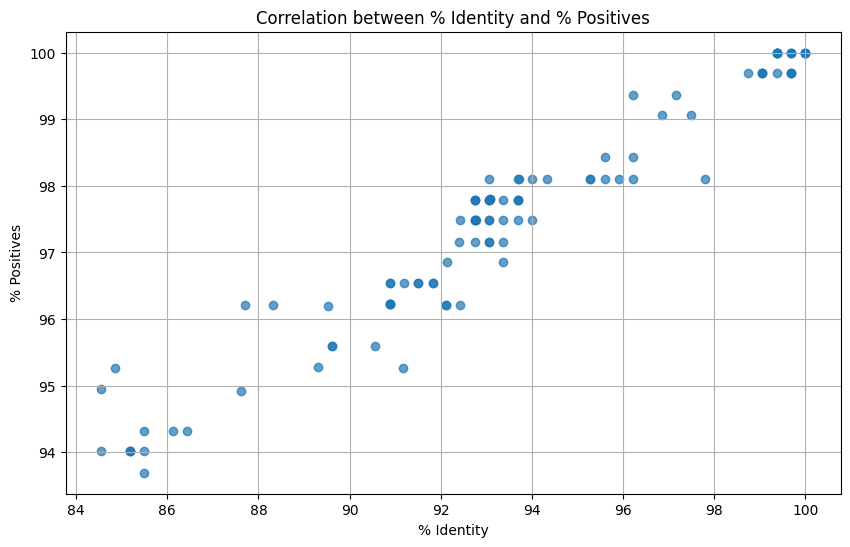

In [101]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['% identity'], df['% positives'], alpha=0.7)

# Add labels and title
plt.xlabel('% Identity')
plt.ylabel('% Positives')
plt.title('Correlation between % Identity and % Positives')

# Display the plot
plt.grid(True)
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [102]:
protein_source_url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv'
df_protein_source = pd.read_csv(protein_source_url)

protein_map = df_protein_source.set_index('Protein')['Source']

df['Protein source'] = df.index.map(protein_map).fillna('NA')

df

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947,47.0,NA
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319,41.0,NA
AHG32084.1,99.371,318.0,2.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,18964,3.0,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318.0,23.0,0.0,1.0,318.0,1.0,318.0,0.0,551.0,97.48,17348,6.0,NA
ASP44815.1,93.375,317.0,21.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,96.85,7105,19.0,NA
YP_009414156.1,84.543,317.0,49.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,94.01,18940,37.0,GenPept
